In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('attention_span_dataset.csv')
df

,session_duration_sec,scroll_depth_pct,clicks_per_minute,idle_time_sec,mouse_movement_dist,tab_switches,attention_span
0,3204,3.467270,15.0,8.039262,371.793402,2,high
1,3537,39.191056,25.0,32.488339,326.825416,2,high
2,890,69.716369,14.0,25.549884,NaN,1,high
3,1324,19.343534,17.0,12.250233,371.111824,3,low
4,1160,64.150448,21.0,12.632498,599.538044,1,high
...,...,...,...,...,...,...,...
6995,253,94.865616,12.0,NaN,568.877083,4,low
6996,813,64.149037,15.0,20.871440,559.903897,2,low
6997,3247,87.691893,12.0,27.806037,241.402996,0,high
6998,3042,67.605601,NaN,39.561735,650.006921,1,high


In [146]:
df.shape

(7000, 7)

In [147]:
df.columns

Index(['session_duration_sec', 'scroll_depth_pct', 'clicks_per_minute',
       'idle_time_sec', 'mouse_movement_dist', 'tab_switches',
       'attention_span'],
      dtype='object')

In [148]:
df.dtypes

session_duration_sec      int64
scroll_depth_pct        float64
clicks_per_minute       float64
idle_time_sec           float64
mouse_movement_dist     float64
tab_switches              int64
attention_span           object
dtype: object

In [149]:
df.head()

,session_duration_sec,scroll_depth_pct,clicks_per_minute,idle_time_sec,mouse_movement_dist,tab_switches,attention_span
0,3204,3.467270,15.0,8.039262,371.793402,2,high
1,3537,39.191056,25.0,32.488339,326.825416,2,high
2,890,69.716369,14.0,25.549884,NaN,1,high
3,1324,19.343534,17.0,12.250233,371.111824,3,low
4,1160,64.150448,21.0,12.632498,599.538044,1,high


In [150]:
df.tail()

,session_duration_sec,scroll_depth_pct,clicks_per_minute,idle_time_sec,mouse_movement_dist,tab_switches,attention_span
6995,253,94.865616,12.0,NaN,568.877083,4,low
6996,813,64.149037,15.0,20.871440,559.903897,2,low
6997,3247,87.691893,12.0,27.806037,241.402996,0,high
6998,3042,67.605601,NaN,39.561735,650.006921,1,high
6999,979,35.698369,21.0,142.452634,761.575385,1,low


In [151]:
df.isna().sum()

session_duration_sec      0
scroll_depth_pct        672
clicks_per_minute       542
idle_time_sec           545
mouse_movement_dist     611
tab_switches              0
attention_span            0
dtype: int64

In [152]:
df['scroll_depth_pct']=df['scroll_depth_pct'].fillna(df['scroll_depth_pct'].mean())
df['clicks_per_minute']=df['clicks_per_minute'].fillna(df['clicks_per_minute'].mean())
df['idle_time_sec']=df['idle_time_sec'].fillna(df['idle_time_sec'].mean())
df['mouse_movement_dist']=df['mouse_movement_dist'].fillna(df['mouse_movement_dist'].median())


In [153]:
df.isna().sum()

session_duration_sec    0
scroll_depth_pct        0
clicks_per_minute       0
idle_time_sec           0
mouse_movement_dist     0
tab_switches            0
attention_span          0
dtype: int64

In [154]:
df['attention_span'].value_counts()

attention_span
high    3500
low     3500
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Attention Levels')

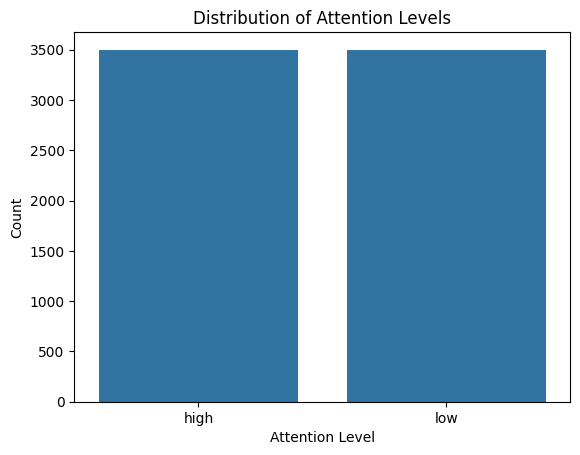

In [155]:
sns.countplot(x="attention_span", data=df)
plt.xlabel("Attention Level")
plt.ylabel("Count")
plt.title("Distribution of Attention Levels")

In [156]:
df['attention_span'].unique()

array(['high', 'low'], dtype=object)

In [157]:
x=df.iloc[:,:-1].values
y=df.iloc[:,-1].values
x

array([[3.20400000e+03, 3.46727042e+00, 1.50000000e+01, 8.03926234e+00,
        3.71793402e+02, 2.00000000e+00],
       [3.53700000e+03, 3.91910563e+01, 2.50000000e+01, 3.24883394e+01,
        3.26825416e+02, 2.00000000e+00],
       [8.90000000e+02, 6.97163692e+01, 1.40000000e+01, 2.55498843e+01,
        4.95657993e+02, 1.00000000e+00],
       ...,
       [3.24700000e+03, 8.76918932e+01, 1.20000000e+01, 2.78060374e+01,
        2.41402996e+02, 0.00000000e+00],
       [3.04200000e+03, 6.76056005e+01, 1.49883865e+01, 3.95617347e+01,
        6.50006921e+02, 1.00000000e+00],
       [9.79000000e+02, 3.56983692e+01, 2.10000000e+01, 1.42452634e+02,
        7.61575385e+02, 1.00000000e+00]], shape=(7000, 6))

In [158]:
y

array(['high', 'high', 'high', ..., 'high', 'high', 'low'],
      shape=(7000,), dtype=object)

In [159]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=1)

In [160]:
x_train

array([[1.74900000e+03, 1.97555906e+01, 1.30000000e+01, 4.78337306e+01,
        7.54148818e+02, 0.00000000e+00],
       [1.17400000e+03, 1.94958271e+01, 1.90000000e+01, 4.68926310e+01,
        6.85117520e+02, 0.00000000e+00],
       [3.19300000e+03, 7.89673614e+01, 1.49883865e+01, 4.66400014e+01,
        7.35427215e+02, 2.00000000e+00],
       ...,
       [3.02800000e+03, 6.54775751e+01, 1.10000000e+01, 8.87395870e+00,
        4.95657993e+02, 5.00000000e+00],
       [3.47500000e+03, 9.34729915e+01, 1.30000000e+01, 1.21939421e+01,
        3.22108670e+02, 3.00000000e+00],
       [2.21000000e+02, 4.93374223e+01, 1.40000000e+01, 4.85183900e+01,
        3.96939470e+02, 0.00000000e+00]], shape=(4900, 6))

In [161]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(x_train)
x_train=scaler.transform(x_train)
x_test=scaler.transform(x_test)
x_train

array([[-8.19159291e-02, -1.09482100e+00, -5.32839362e-01,
         6.41690404e-01,  1.74977994e+00, -1.43688171e+00],
       [-6.42283741e-01, -1.10436989e+00,  1.09630255e+00,
         6.08885906e-01,  1.28243081e+00, -1.43688171e+00],
       [ 1.32533819e+00,  1.08180153e+00,  7.05460222e-03,
         6.00079841e-01,  1.62303273e+00, -3.21842778e-03],
       ...,
       [ 1.16453700e+00,  5.85917481e-01, -1.07588667e+00,
        -7.16354746e-01, -2.30084661e-04,  2.14727650e+00],
       [ 1.60016206e+00,  1.61502797e+00, -5.32839362e-01,
        -6.00628006e-01, -1.17517722e+00,  7.13613215e-01],
       [-1.57103248e+00, -7.39394793e-03, -2.61315709e-01,
         6.65556006e-01, -6.68564846e-01, -1.43688171e+00]],
      shape=(4900, 6))

In [164]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
y_pred

array(['low', 'high', 'low', ..., 'high', 'low', 'high'],
      shape=(2100,), dtype=object)

In [165]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cm = confusion_matrix(y_test,y_pred)
score = accuracy_score(y_test,y_pred)
report = classification_report(y_test,y_pred)
cm

array([[982,  61],
       [ 59, 998]])

In [166]:
score*100

94.28571428571428

In [167]:
print(report)

              precision    recall  f1-score   support

        high       0.94      0.94      0.94      1043
         low       0.94      0.94      0.94      1057

    accuracy                           0.94      2100
   macro avg       0.94      0.94      0.94      2100
weighted avg       0.94      0.94      0.94      2100



In [168]:
import pickle

with open("attention_model.pkl", "wb") as f:
    pickle.dump(model, f)